In [1]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
# Cargar el dataset
df = pd.read_csv('/Users/kevinmr/Workspace/PORTAFOLIO/credit_card_fraud_detection/data/creditcard.csv')

In [4]:
# Variables seleccionadas
features = ['V14', 'V17', 'V12', 'V10']
target = 'Class'

X = df[features]
y = df[target]

In [5]:
# División 70% entrenamiento / 30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  # Esto mantiene la proporción de fraudes igual en ambos sets
)

Reporte de Clasificación:

              precision    recall  f1-score   support

           0     0.9996    0.9996    0.9996     85295
           1     0.7973    0.7973    0.7973       148

    accuracy                         0.9993     85443
   macro avg     0.8985    0.8985    0.8985     85443
weighted avg     0.9993    0.9993    0.9993     85443



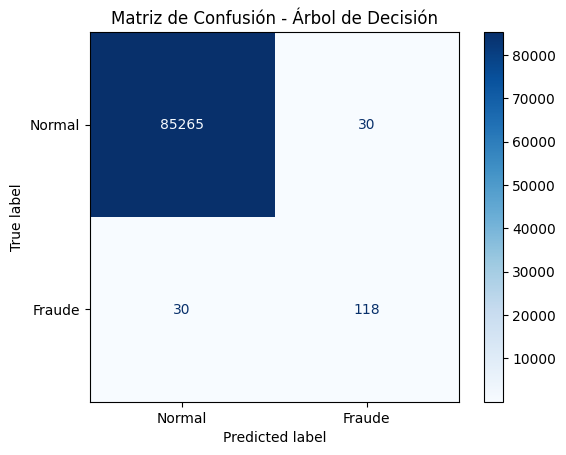

In [6]:
# 5. Entrenamiento del Modelo

# Crear el modelo de Árbol de Decisión
clf = DecisionTreeClassifier(random_state=42, max_depth=5)  # Limitamos la profundidad para evitar overfitting
clf.fit(X_train, y_train)  # Entrenar el modelo

# 6. Evaluación del Modelo

# Realizar predicciones sobre el conjunto de prueba
y_pred = clf.predict(X_test)

# Mostrar reporte de clasificación
print("Reporte de Clasificación:\n")
print(classification_report(y_test, y_pred, digits=4))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar matriz de confusión de forma gráfica
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraude"])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()

Reporte de Clasificación - Random Forest:

              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9997     85295
           1     0.9187    0.7635    0.8339       148

    accuracy                         0.9995     85443
   macro avg     0.9591    0.8817    0.9168     85443
weighted avg     0.9994    0.9995    0.9994     85443



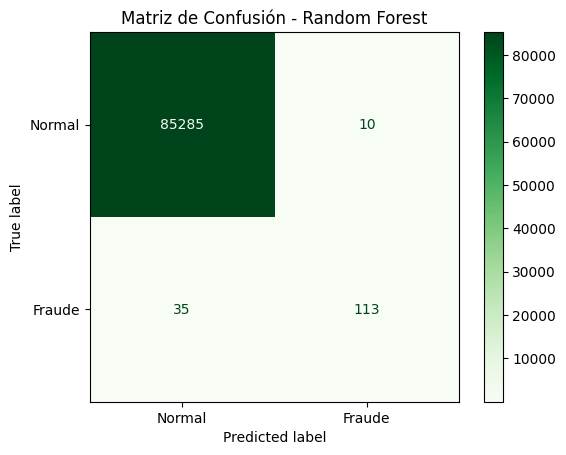

In [7]:
# Importar RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Crear modelo de Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # Número de árboles
    max_depth=8,           # Máxima profundidad de los árboles
    random_state=42,       # Para reproducibilidad
    n_jobs=-1              # Usa todos los núcleos de tu procesador para hacerlo más rápido
)

# Entrenar modelo
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Reporte de clasificación
print("Reporte de Clasificación - Random Forest:\n")
print(classification_report(y_test, y_pred_rf, digits=4))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Mostrar matriz de confusión de forma gráfica
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Normal", "Fraude"])
disp_rf.plot(cmap='Greens')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

In [8]:
# Crear archivo para Power BI
dashboard_df = df[['Amount', 'Time', 'V14', 'V17', 'V12', 'V10', 'Class']]
dashboard_df.to_csv('../dashboard/dashboard_data.csv', index=False)